# XGBoost con solo las features estilométricas

Como vimos en el notbook `03_supervised_ml_methods.ipynb`, los modelos que usan solo las features estilométricas obtienen un rendimiento bastante bueno, aunque no tan alto como el modelo que usa solo las palabras funcionales o las features combinadas.

Ahora queremos comprobar si usando un modelo más robusto como **XGBoost** podemos mejorar el rendimiento de las features estilométricas y acercarnos al rendimiento de las palabras funcionales. Para ello, vamos a entrenar un modelo de XGBoost usando únicamente las features estilométricas y evaluarlo en el conjunto de test.

In [1]:
from xgboost import XGBClassifier
import xgboost as xgb

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, make_scorer
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, train_test_split

from whodunit_stylometry.utils.plot_utils import plot_confussion_matrix

## Configuración

In [2]:
SEED = 42
INPUT_PATH = Path("../output/tables")
CORPUS_PATH = Path("../corpus")

## Carga de datos

In [3]:
# Cargamos las métricas previamente calculadas para el
# corpus completo (train + test) y las mostramos
df = pd.read_csv(INPUT_PATH / "corpus_eda_metrics.csv")
print(df.shape)
df.head()

(95, 72)


,file_name,author,title,year,type,detective,genre,language,country,source,...,period_count_per_1000,semicolon_count_per_1000,colon_count_per_1000,exclam_count_per_1000,question_count_per_1000,ellipsis_count_per_1000,quote_count_per_1000,dialog_dash_count_per_1000,hyphen_count_per_1000,parenthesis_count_per_1000
0,acd-a_study_in_scarlet.txt,A.C. Doyle,A Study in Scarlet,1887,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.707677,1.975159,0.265887,1.614312,3.969309,0.189919,32.248262,2.032134,4.937896,0.075968
1,acd-tales_of_terror_and_mystery.txt,A.C. Doyle,Tales of Terror and Mystery,1890,short stories,NaN,terror,en,UK,Project Gutemberg USA,...,43.183733,1.033534,0.752682,1.819918,3.089367,0.179745,19.479863,2.909622,5.392350,0.584171
2,acd-the_adventures_of_sherlock_holmes.txt,A.C. Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.671439,1.554169,0.430859,2.662091,5.678102,0.123102,39.154286,1.346433,5.678102,0.076939
3,acd-the_case_book_of_sherlock_holmes.txt,A.C. Doyle,The case-book of Sherlock Holmes,1921,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,57.387639,0.650808,0.233125,3.224898,7.129744,0.437110,41.107733,3.312320,5.235602,0.038854
4,acd-the_hound_of_the_baskervilles.txt,A.C. Doyle,The Hound of the Baskervilles,1901,novel,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.648868,0.626226,0.222658,2.532738,7.208561,0.264407,38.561628,1.906511,3.687777,0.139161


In [4]:
# Eliminamos la extensión de los nombres de los
# archivos para facilitar su manejo
df["file_name"] = df["file_name"].str[:-4]

## Obtener conjuntos de entrenamiento y test

In [5]:
test_rows = []

for author, g_author in df.groupby("author_norm"):
    mystery_pool = g_author[g_author["genre"] == "mystery"]
    non_mystery_pool = g_author[g_author["genre"] != "mystery"]

    mystery_pick = mystery_pool.sample(n=1, random_state=SEED)
    non_mystery_pick = non_mystery_pool.sample(n=1, random_state=SEED)

    test_rows.append(mystery_pick)
    test_rows.append(non_mystery_pick)

test_df = pd.concat(test_rows, axis=0).drop_duplicates(subset=["title_norm"]).copy()
test_df

,file_name,author,title,year,type,detective,genre,language,country,source,...,period_count_per_1000,semicolon_count_per_1000,colon_count_per_1000,exclam_count_per_1000,question_count_per_1000,ellipsis_count_per_1000,quote_count_per_1000,dialog_dash_count_per_1000,hyphen_count_per_1000,parenthesis_count_per_1000
43,akg-three_thousand_dollars,A.K. Green,Three Thousand Dollars,1910,novel,NaN,mystery,en,USA,Project Gutemberg USA,...,56.481481,4.828042,0.462963,3.902116,6.415344,1.917989,35.912698,4.695767,2.248677,0.264550
44,akg-to_the_minute,A.K. Green,To the Minute,1916,novel,NaN,fiction,en,USA,Project Gutemberg AU,...,39.053870,4.462062,1.884463,2.577599,4.397080,0.714796,18.086512,4.483722,2.707562,0.909741
2,acd-the_adventures_of_sherlock_holmes,A.C. Doyle,The Adventures of Sherlock Holmes,1892,short stories,Sherlock Holmes,mystery,en,UK,Project Gutemberg USA,...,47.671439,1.554169,0.430859,2.662091,5.678102,0.123102,39.154286,1.346433,5.678102,0.076939
5,acd-the_lost_world,A.C. Doyle,The Lost World,1912,novel,NaN,scifi,en,UK,Project Gutemberg USA,...,42.786201,1.129126,0.449458,3.124281,3.924535,0.241173,24.522862,3.595663,7.366725,1.359336
47,am-chronicles_of_martin_hewitt,A. Morrison,Chronicles of Martin Hewitt,1895,short stories,Martin Hewit,mystery,en,UK,Project Gutemberg USA,...,45.504109,2.632909,0.492008,1.396239,5.850908,0.345735,30.265153,7.326933,5.771123,1.196777
51,am-the_hole_in_the_wall,A. Morrison,The Hole in the Wall,1902,novel,NaN,fiction,en,UK,Project Gutemberg USA,...,39.462081,10.141093,1.653439,5.658436,6.711738,1.200274,29.443465,6.319812,5.976876,0.367431
52,gkc-four_faultless_felons,G.K. Chesterton,Four Faultless Felons,1930,short stories,NaN,mystery,en,UK,Project Gutemberg AU,...,39.750305,4.938892,1.925331,1.040396,3.396235,0.861017,30.697663,0.155461,4.592093,0.430509
64,gkc-the_return_of_don_quixote,G.K. Chesterton,The Return of Don Quixote,1927,novel,NaN,fiction,en,UK,Project Gutemberg AU,...,39.971325,11.354308,0.693746,0.647496,3.283731,1.052181,31.091378,1.271867,4.879346,0.855620
83,raf-the_shadow_of_the_wolf,R.A. Freeman,The shadow of the Wolf,1925,novel,Dr. Thorndyke,mystery,en,UK,Project Gutemberg USA,...,46.870534,6.573307,1.111429,0.910313,4.996136,0.074095,32.273771,2.995565,5.557143,0.317551
78,raf-the_golden_pool,R.A. Freeman,The golden pool,1905,novel,NaN,fiction,en,UK,Project Gutemberg USA,...,28.206819,5.144101,0.296775,1.233265,2.354415,0.039570,20.820418,3.198575,6.087186,1.094770


In [6]:
# Train = resto
train_df = df.loc[~df.index.isin(test_df.index)].copy()

print("Train set shape:", train_df.shape)
print("Test set shape:", test_df.shape)

Train set shape: (83, 72)
Test set shape: (12, 72)


## Selección de características

Dado que XGboost es un modelo robusto frente a la multicolinealidad, no es necesario eliminar características altamente correlacionadas. De esta forma, seleccionamos todas las features estilométricas disponibles para entrenar el modelo.

In [7]:
base_features = [
    "non_alpha_ratio",
    "digit_ratio",
    "whitespace_ratio",
    "non_alpha_token_ratio",
    "avg_sentence_len",
    "median_sentence_len",
    "std_sentence_len",
    "sentences_per_1000_tokens",
    "short_sentence_ratio",
    "long_sentence_ratio",
    "avg_paragraph_len",
    "median_paragraph_len",
    "std_paragraph_len",
    "paragraphs_per_1000_tokens",
    "avg_sentences_per_paragraph",
    "median_sentences_per_paragraph",
    "hapax_ratio",
    "avg_word_len",
    "long_word_ratio",
    "mattr_100",
    "stopword_ratio",
    "comma_count_per_1000",
    "period_count_per_1000",
    "semicolon_count_per_1000",
    "colon_count_per_1000",
    "exclam_count_per_1000",
    "question_count_per_1000",
    "ellipsis_count_per_1000",
    "quote_count_per_1000",
    "dialog_dash_count_per_1000",
    "hyphen_count_per_1000",
    "parenthesis_count_per_1000",
]

In [8]:
train_base = train_df[["file_name", "author_norm"] + base_features].copy()
test_base = test_df[["file_name", "author_norm"] + base_features].copy()

print("Train set shape:", train_base.shape)
print("Test set shape:", test_base.shape)

Train set shape: (83, 34)
Test set shape: (12, 34)


In [9]:
print("Dataset base features:", train_base.columns)

Dataset base features: Index(['file_name', 'author_norm', 'non_alpha_ratio', 'digit_ratio',
       'whitespace_ratio', 'non_alpha_token_ratio', 'avg_sentence_len',
       'median_sentence_len', 'std_sentence_len', 'sentences_per_1000_tokens',
       'short_sentence_ratio', 'long_sentence_ratio', 'avg_paragraph_len',
       'median_paragraph_len', 'std_paragraph_len',
       'paragraphs_per_1000_tokens', 'avg_sentences_per_paragraph',
       'median_sentences_per_paragraph', 'hapax_ratio', 'avg_word_len',
       'long_word_ratio', 'mattr_100', 'stopword_ratio',
       'comma_count_per_1000', 'period_count_per_1000',
       'semicolon_count_per_1000', 'colon_count_per_1000',
       'exclam_count_per_1000', 'question_count_per_1000',
       'ellipsis_count_per_1000', 'quote_count_per_1000',
       'dialog_dash_count_per_1000', 'hyphen_count_per_1000',
       'parenthesis_count_per_1000'],
      dtype='str')


Ahora que tenemos los conjuntos de entrenamiento y test con las features estilométricas, podemos proceder a quedarnos con las características de entrada y la etiqueta de salida para entrenar el modelo de XGBoost.

In [10]:
X_train = train_base[base_features].copy()
X_test = test_base[base_features].copy()

y_train_raw = train_base["author_norm"].copy()
y_test_raw = test_base["author_norm"].copy()

# Codificamos las etiquetas de autor para que sean
# numéricas y compatibles con el modelo de XGBoost
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_raw)
y_test = label_encoder.transform(y_test_raw)

class_names = list(label_encoder.classes_)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Clases:", class_names)

X_train: (83, 32)
y_train: (83,)
X_test: (12, 32)
y_test: (12,)
Clases: ['anna_katharine_green', 'arthur_conan_doyle', 'arthur_morrison', 'gilbert_keith_chesterton', 'richard_austin_freeman', 'wilkie_collins']


## Configuración del modelo XGBoost

Vamos a usar realizar una búsqueda de hiperparámetros para encontrar la mejor configuración del modelo de XGBoost. Para ello, vamos a definir un espacio de búsqueda con los hiperparámetros más importantes y luego usaremos `RandomizedSearchCV` para encontrar la mejor combinación.

In [11]:
xgb_model = XGBClassifier(objective="multi:softprob", eval_metric="mlogloss", random_state=SEED, n_jobs=-1)

param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [2, 3, 4, 5],
    "min_child_weight": [1, 2, 4, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.3, 1.0],
    "reg_alpha": [0, 0.1, 0.5, 1.0],
    "reg_lambda": [1, 2, 5, 10],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=150,
    scoring=make_scorer(f1_score, average="macro"),
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=SEED,
)

search.fit(X_train, y_train)
print("Mejores parámetros:", search.best_params_)
print("Mejor puntuación:", search.best_score_)

Fitting 3 folds for each of 150 candidates, totalling 450 fits


Mejores parámetros: {'subsample': 0.8, 'reg_lambda': 10, 'reg_alpha': 0, 'n_estimators': 1200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Mejor puntuación: 0.7948067632850241


Una vez que tengamos la mejor configuración, instanciamos el modelo de XGBoost con esos hiperparámetros.

Vamos a añadir un callback de early stopping para intentar mitigar el sobreajuste durante el entrenamiento. Esto nos permitirá detener el entrenamiento si el rendimiento en el conjunto de validación no mejora después de un número determinado de rondas.

In [12]:
early_stop = xgb.callback.EarlyStopping(rounds=30, metric_name="mlogloss", data_name="validation_0", save_best=True)


xgb_model = XGBClassifier(
    **search.best_params_,
    callbacks=[early_stop],
)

xgb_model

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",[<xgboost.call...t 0x1599adf90>]
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.dat

## Entrenamiento

Para poder usar el early stopping, necesitamos dividir el conjunto de entrenamiento en un conjunto de entrenamiento propiamente dicho y un conjunto de validación. Para ello, vamos a usar `train_test_split` para crear un conjunto de validación a partir del conjunto de entrenamiento.

In [13]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

In [14]:
xgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",[<xgboost.call...t 0x1599adf90>]
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.data

In [15]:
print("Mejor iteración:", xgb_model.best_iteration)
print("Mejor puntuación (mlogloss):", xgb_model.best_score)

Mejor iteración: 736
Mejor puntuación (mlogloss): 0.3212307605563718


In [16]:
results = xgb_model.evals_result()
metric_name = list(results["validation_0"].keys())[0]
print("Número de iteraciones:", len(results["validation_0"][metric_name]))

Número de iteraciones: 767


Dado que el mejor resultado de validación se alcanzó en la iteración 736 y el entrenamiento finalizó en la 767, el valor `early_stopping_rounds=30` no parece estar deteniendo el entrenamiento de forma prematura. Por tanto, este valor puede considerarse adecuado en esta configuración, ya que permite al modelo converger antes de activar la parada temprana.

## Predicción y evaluación global

En esta sección evaluamos el rendimiento global del modelo en los conjuntos de entrenamiento y test.

In [17]:
# Evaluamos el modelo en el conjunto de
# entrenamiento para ver su rendimiento
y_pred_train = xgb_model.predict(X_train)
print("F1 Score (Train): %.4f" % f1_score(y_train, y_pred_train, average="macro"))

F1 Score (Train): 0.9576


In [18]:
y_pred = xgb_model.predict(X_test)
print("F1 Score (Test) %.4f" % f1_score(y_test, y_pred, average="macro"))

F1 Score (Test) 0.7500


In [19]:
xgb_results = {
    "model_name": "xgboost_base_features",
    "test_accuracy": accuracy_score(y_test, y_pred),
    "test_f1_macro": f1_score(y_test, y_pred, average="macro"),
    "test_f1_weighted": f1_score(y_test, y_pred, average="weighted"),
    "n_features": len(base_features),
    "n_train_samples": X_train.shape[0],
    "n_test_samples": X_test.shape[0],
}

pd.DataFrame([xgb_results])

,model_name,test_accuracy,test_f1_macro,test_f1_weighted,n_features,n_train_samples,n_test_samples
0,xgboost_base_features,0.75,0.75,0.75,32,83,12


Como vemos, parece que el modelo de XGBoost no solo no mejora el rendimiento sino que empeora con respecto al mejor modelo de Logistic Regression entrenado en el notebook `03_supervised_ml_methods.ipynb` usando las mismas base features.

Además, parece existir un importante sobreajuste, ya que el rendimiento en el conjunto de entrenamiento es bastante alto (0.96) mientras que en el test es bastante más bajo (0.75).

### Informe de clasificación

In [20]:
print("\n=== INFORME DE CLASIFICACIÓN EN TEST DE XGBOOST CON BASE FEATURES ===")
print(classification_report(y_test, y_pred, target_names=class_names, zero_division=0))


=== INFORME DE CLASIFICACIÓN EN TEST DE XGBOOST CON BASE FEATURES ===
                          precision    recall  f1-score   support

    anna_katharine_green       0.50      0.50      0.50         2
      arthur_conan_doyle       1.00      1.00      1.00         2
         arthur_morrison       1.00      0.50      0.67         2
gilbert_keith_chesterton       0.50      1.00      0.67         2
  richard_austin_freeman       1.00      0.50      0.67         2
          wilkie_collins       1.00      1.00      1.00         2

                accuracy                           0.75        12
               macro avg       0.83      0.75      0.75        12
            weighted avg       0.83      0.75      0.75        12



### Matriz de confusión

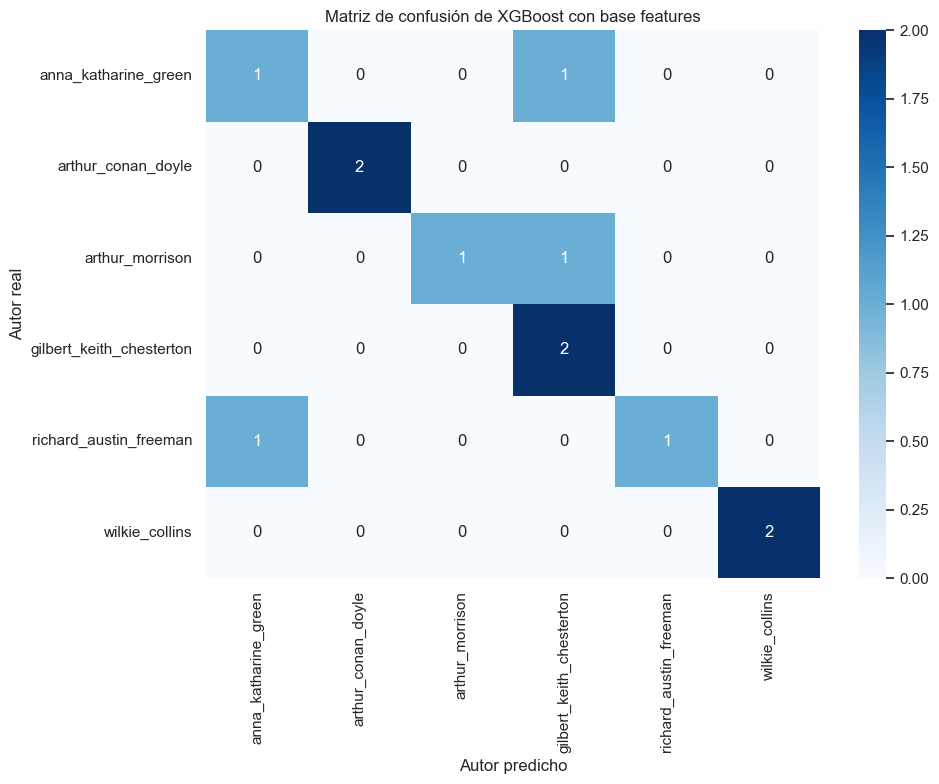

In [21]:
cm = confusion_matrix(y_test, y_pred)

plot_confussion_matrix(cm=cm, labels=class_names, model_name="XGBoost", features="base features")

### Predicciones detalladas sobre test

In [22]:
# `author_norm` -> `y_true`
predictions_df = test_base[["file_name", "author_norm"]].copy()
predictions_df["y_pred"] = label_encoder.inverse_transform(y_pred)
predictions_df["correct"] = predictions_df["author_norm"] == predictions_df["y_pred"]

predictions_df

,file_name,author_norm,y_pred,correct
43,akg-three_thousand_dollars,anna_katharine_green,gilbert_keith_chesterton,False
44,akg-to_the_minute,anna_katharine_green,anna_katharine_green,True
2,acd-the_adventures_of_sherlock_holmes,arthur_conan_doyle,arthur_conan_doyle,True
5,acd-the_lost_world,arthur_conan_doyle,arthur_conan_doyle,True
47,am-chronicles_of_martin_hewitt,arthur_morrison,arthur_morrison,True
51,am-the_hole_in_the_wall,arthur_morrison,gilbert_keith_chesterton,False
52,gkc-four_faultless_felons,gilbert_keith_chesterton,gilbert_keith_chesterton,True
64,gkc-the_return_of_don_quixote,gilbert_keith_chesterton,gilbert_keith_chesterton,True
83,raf-the_shadow_of_the_wolf,richard_austin_freeman,richard_austin_freeman,True
78,raf-the_golden_pool,richard_austin_freeman,anna_katharine_green,False


### Errores de clasificación

In [23]:
errors_df = predictions_df.loc[~predictions_df["correct"]].copy()
errors_df

,file_name,author_norm,y_pred,correct
43,akg-three_thousand_dollars,anna_katharine_green,gilbert_keith_chesterton,False
51,am-the_hole_in_the_wall,arthur_morrison,gilbert_keith_chesterton,False
78,raf-the_golden_pool,richard_austin_freeman,anna_katharine_green,False


## Importancia global de las features

Aquí se muestra la importancia global de las features según el modelo de XGBoost.

In [24]:
xgb_importance_df = (
    pd.DataFrame({"feature": base_features, "importance": xgb_model.feature_importances_})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

xgb_importance_df.head(20)

,feature,importance
0,semicolon_count_per_1000,0.097315
1,std_sentence_len,0.091956
2,short_sentence_ratio,0.089750
3,std_paragraph_len,0.080133
4,long_word_ratio,0.070159
5,hyphen_count_per_1000,0.048225
6,dialog_dash_count_per_1000,0.047404
7,long_sentence_ratio,0.046643
8,hapax_ratio,0.044211
9,parenthesis_count_per_1000,0.039812


Mostramos lo anterior en forma de gráfico de barras ordenado por importancia.

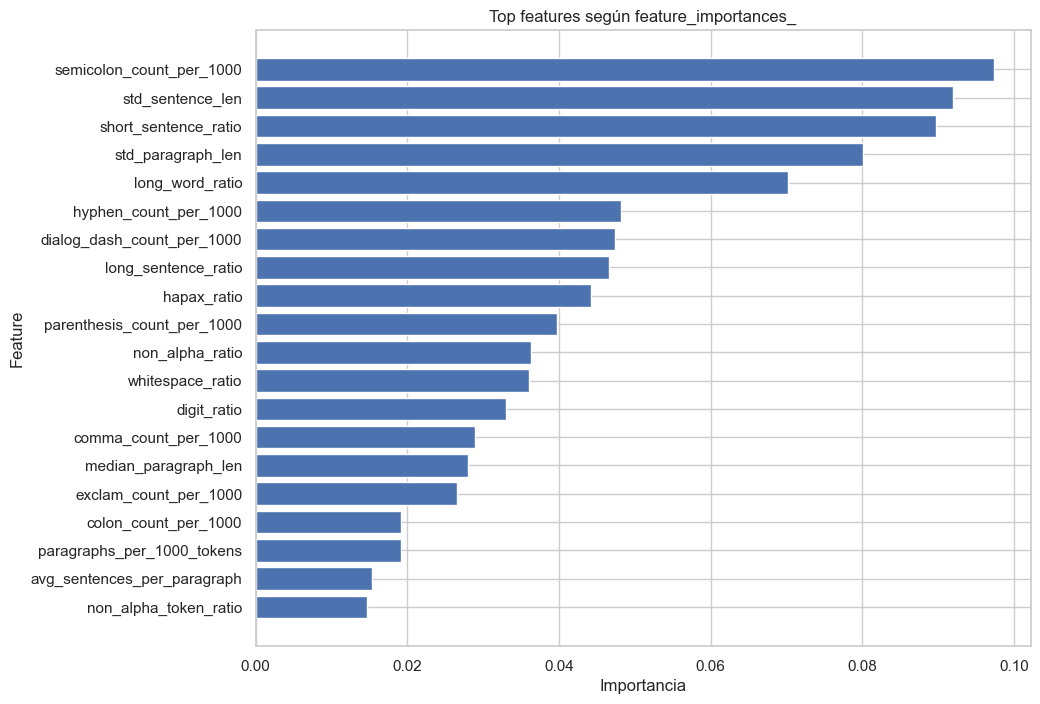

In [25]:
plt.figure(figsize=(10, 8))
top_k = min(20, len(xgb_importance_df))
plt.barh(xgb_importance_df["feature"].head(top_k)[::-1], xgb_importance_df["importance"].head(top_k)[::-1])
plt.title("Top features según feature_importances_")
plt.xlabel("Importancia")
plt.ylabel("Feature")
plt.show()

Las importancias obtenidas mediante `feature_importances_` en XGBoost reflejan la contribución relativa de cada variable al proceso de partición de los árboles del modelo. En este contexto, valores más altos indican que una feature ha resultado más útil para generar divisiones que mejoran la clasificación, aunque no deben interpretarse como coeficientes con signo ni como efectos directos sobre una clase concreta. Por tanto, estas importancias permiten identificar qué variables han sido más aprovechadas por el modelo, pero no indican si una feature favorece o perjudica a un autor específico.

En los resultados obtenidos, las variables con mayor importancia corresponden principalmente a dos tipos de rasgos: por un lado, **hábitos de puntuación** como `semicolon_count_per_1000`, `hyphen_count_per_1000`, `dialog_dash_count_per_1000` o `comma_count_per_1000` y, por otro, **medidas de variabilidad estructural** como `std_sentence_len`, `short_sentence_ratio` y `std_paragraph_len`.

También aparecen con una relevancia moderada variables vinculadas a la complejidad léxica y a rasgos superficiales del texto, como `long_word_ratio`, `hapax_ratio`, `non_alpha_ratio` o `digit_ratio`. Así, estos resultados indican que la señal capturada por XGBoost no depende de una única dimensión estilística, sino de la combinación de varios rasgos formales y estructurales.

No obstante, estas importancias deben interpretarse con cautela. En primer lugar, se trata de una medida global del uso de las variables dentro del modelo, no de una explicación local de predicciones individuales. En segundo lugar, cuando existen features correlacionadas, la importancia puede repartirse entre varias variables similares o concentrarse en una sola de ellas de forma algo arbitraria. Por ello, este análisis resulta útil para detectar qué bloques de rasgos están siendo explotados por el modelo, pero no debe entenderse como una prueba definitiva de causalidad ni como una jerarquía absoluta de relevancia estilística.

In [26]:
perm = permutation_importance(xgb_model, X_test, y_test, n_repeats=20, random_state=SEED, scoring="f1_macro")

perm_df = pd.DataFrame(
    {"feature": X_test.columns, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std}
).sort_values("importance_mean", ascending=False)

perm_df.head(20)

,feature,importance_mean,importance_std
23,semicolon_count_per_1000,0.187341,0.093046
6,std_sentence_len,0.171548,0.118206
21,comma_count_per_1000,0.137222,0.031481
16,hapax_ratio,0.109484,0.113208
0,non_alpha_ratio,0.108333,0.062546
29,dialog_dash_count_per_1000,0.072222,0.072222
31,parenthesis_count_per_1000,0.043333,0.066193
2,whitespace_ratio,0.000000,0.000000
8,short_sentence_ratio,0.000000,0.000000
9,long_sentence_ratio,0.000000,0.000000


El análisis de *permutation importance* muestra que el modelo XGBoost depende principalmente de un conjunto reducido de variables. En particular, destacan `semicolon_count_per_1000`, `std_sentence_len` y `comma_count_per_1000`, cuya permutación provoca la mayor caída en el rendimiento, lo que indica que son las features más útiles para la clasificación. También aportan información `hapax_ratio` y `non_alpha_ratio`, aunque con mayor variabilidad entre repeticiones.

En cambio, un número amplio de variables presenta importancia media nula, lo que sugiere que su permutación no altera apreciablemente el rendimiento del modelo. Esto indica que dichas features no están siendo aprovechadas de forma efectiva por XGBoost o bien que su información ya está recogida por otras variables correlacionadas. De este modo, los resultados apuntan a que el modelo se apoya sobre todo en hábitos de puntuación y en rasgos de variabilidad estructural del texto, mientras que muchas de las demás base features parecen redundantes o poco informativas en este contexto.

## Comparativa con el modelo de Regression Logística

Vemos que empeora el rendimiento de **XGBoost** respecto al del mejor modelo de **Logistic Regression** entrenado en el notebook `03_supervised_ml_methods.ipynb` usando las mismas base features.

Esto sugiere que la información relevante para la clasificación se organiza de forma aproximadamente lineal en ese espacio de variables. Dado que XGBoost modela relaciones no lineales e interacciones más complejas, su menor rendimiento apunta a que esa complejidad adicional no resulta beneficiosa en este caso y puede favorecer el sobreajuste.